###  Implemention of  Hyperparameter Tuning using GridSearchCV / RandomizedSearchCV, we will be using fake news dataset for this project

In [39]:
# import alll the required libraries
import pandas as pd              # For data handling
import numpy as np               # For numerical operations
import re                        # For text cleaning (regex)
import nltk                      # NLP toolkit
import pickle                    # To save/load models

# NLTK tools
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from nltk.tokenize import word_tokenize
from nltk import pos_tag
import contractions
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

# Scikit-learn tools
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

# Machine Learning Models
from sklearn.linear_model import LogisticRegression

# Evaluation Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# remove warnings
import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to C:\Users\Saif
[nltk_data]     Ullah\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\Saif
[nltk_data]     Ullah\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Saif
[nltk_data]     Ullah\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Saif
[nltk_data]     Ullah\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Saif Ullah\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Saif Ullah\AppData\Roaming\nltk_data...
[nltk_d

In [40]:
# load the dataset
df = pd.read_csv('news_dataset.csv')

In [41]:
#checking the dataset
df.head()

,Text,label
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,Fake
1,U.S. conservative leader optimistic of common ...,Real
2,"Trump proposes U.S. tax overhaul, stirs concer...",Real
3,Court Forces Ohio To Allow Millions Of Illega...,Fake
4,Democrats say Trump agrees to work on immigrat...,Real


In [42]:
#checking the information of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9900 entries, 0 to 9899
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Text    9900 non-null   object
 1   label   9900 non-null   object
dtypes: object(2)
memory usage: 154.8+ KB


In [43]:
# checking the shape of the dataset
df.shape

(9900, 2)

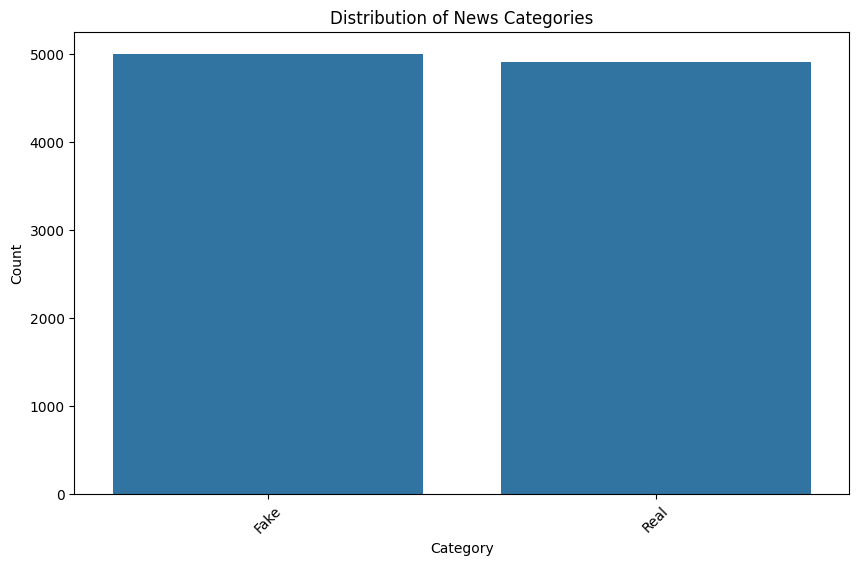

In [44]:
# visualize the distribution of categories
plt.figure(figsize=(10,6))
sns.countplot(x='label', data=df)
plt.title('Distribution of News Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


In [45]:
# checking missing values in the dataset
df.isnull().sum()


Text     0
label    0
dtype: int64

In [46]:
# checking the duplicates values in the dataset
df.duplicated().sum()

35

In [47]:
# print duplicates vlaues in the dataset
df[df.duplicated()]

,Text,label
1576,Highlights: The Trump presidency on April 13 a...,Real
2173,Trump asks Supreme Court to block travel ban r...,Real
2887,Trump tries to rally support for healthcare bi...,Real
3330,Highlights: The Trump presidency on March 31 a...,Real
3401,Highlights: The Trump presidency on April 26 a...,Real
3432,Former Trump security aide was Russia blackmai...,Real
3861,Highlights: The Trump presidency on April 13 a...,Real
4123,Highlights: The Trump presidency on March 31 a...,Real
4525,'Nuclear option' fallout? More extreme U.S. ju...,Real
4727,Highlights: The Trump presidency on April 21 a...,Real


In [48]:
# remove the duplicates values in the dataset
df.drop_duplicates(inplace=True)

In [49]:
# again checking the duplicates values in the dataset
df.duplicated().sum()

0

#### preprocessing and model training

In [50]:
# preprocess the text data using advance text cleaning techniques to improve the performance of the models
# Load stopwords and lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """
    Advanced NLP preprocessing pipeline:
    - Lowercasing
    - Remove URLs and HTML tags
    - Normalize currency and numbers
    - Remove special characters
    - Tokenization (NLTK)
    - POS tagging
    - Lemmatization with POS
    - Stopword removal
    - Remove short tokens
    - Clean extra spaces
    """
    
    # 1. Lowercase
    text = text.lower()
    
    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)
    
    # 3. Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)
    
    # 4. Normalize currency (e.g., $100.50 → money)
    text = re.sub(r'\$\s?\d+(\.\d+)?', ' money ', text)
    
    # 5. Normalize numbers (e.g., 123 → number)
    text = re.sub(r'\d+(\.\d+)?', ' number ', text)
    
    # 6. Remove special characters & punctuation
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    # 7. Tokenization using NLTK
    tokens = word_tokenize(text)
    
    # 8. POS tagging
    pos_tags = pos_tag(tokens)
    
    # 9. Helper function for POS conversion (inside function as requested)
    def get_wordnet_pos(tag):
        if tag.startswith('J'):
            return 'a'  # adjective
        elif tag.startswith('V'):
            return 'v'  # verb
        elif tag.startswith('N'):
            return 'n'  # noun
        elif tag.startswith('R'):
            return 'r'  # adverb
        else:
            return 'n'
    
    # 10. Lemmatization + stopword removal + short word filtering
    cleaned_words = []
    for word, tag in pos_tags:
        if word not in stop_words and len(word) > 2:
            pos = get_wordnet_pos(tag)
            lemma = lemmatizer.lemmatize(word, pos)
            cleaned_words.append(lemma)
    
    # 11. Join tokens
    text = ' '.join(cleaned_words)
    
    # 12. Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

In [51]:
# applying function to the dataset
df['Text'] = df['Text'].apply(preprocess_text)

In [52]:
df.head()

,Text,label
0,top trump surrogate brutally stab back patheti...,Fake
1,conservative leader optimistic common ground h...,Real
2,trump propose tax overhaul stir concern defici...,Real
3,court force ohio allow million illegally purge...,Fake
4,democrat say trump agrees work immigration bil...,Real


In [53]:
# converting data into target and features
X = df['Text']
y = df['label']

In [54]:
# we will convert the target variable into numerical format using LabelEncoder and save the encoder for later use
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [55]:
# Save label encoder for future use
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

In [56]:
# train test split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

In [57]:
# we will use a pipeline to combine the TfidfVectorizer and LogisticRegression model for hyperparameter tuning
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('clf', LogisticRegression(max_iter=1000))
])

In [58]:
# Train model
pipeline.fit(X_train, y_train)

# Predict
baseline_preds = pipeline.predict(X_test)

# Accuracy
baseline_acc = accuracy_score(y_test, baseline_preds)

print("Baseline Accuracy:", baseline_acc)

Baseline Accuracy: 0.99341104916371


In [59]:
# Hyperparameter Tuning using GridSearchCV
# import time to measure the time taken for hyperparameter tuning
import time

# Step 1: Define parameter grid
param_grid = {
    'tfidf__max_features': [3000, 5000],
    'tfidf__ngram_range': [(1,1), (1,2)],
    'clf__C': [0.1, 1, 10],
    'clf__solver': ['liblinear']
}

# Step 2: Create GridSearch object
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)

# Step 3: Start timing
start = time.time()

# Step 4: Train model
grid_search.fit(X_train, y_train)

# Step 5: End timing
grid_time = time.time() - start

# Step 6: Results
print("\nBest Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)
print("GridSearch Time:", grid_time)

Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best Parameters: {'clf__C': 10, 'clf__solver': 'liblinear', 'tfidf__max_features': 3000, 'tfidf__ngram_range': (1, 2)}
Best CV Score: 0.995945100317507
GridSearch Time: 60.736693143844604


In [60]:
grid_preds = grid_search.best_estimator_.predict(X_test)
grid_acc = accuracy_score(y_test, grid_preds)

In [71]:
best_model = grid_search.best_estimator_

with open("best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

In [72]:
# Hyperparameter Tuning using RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV

# define parameter grid for RandomizedSearchCV
param_dist = {
    'tfidf__max_features': [2000, 3000, 5000, 7000],
    'tfidf__ngram_range': [(1,1), (1,2)],
    'clf__C': [0.01, 0.1, 1, 10, 100]
}

#create RandomizedSearchCV object
random_search = RandomizedSearchCV(
    pipeline,
    param_dist,
    n_iter=5,
    cv=3,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# Start timing
start = time.time()

# Train model
random_search.fit(X_train, y_train)


# End timing
random_time = time.time() - start

print("\nBest Random Params:", random_search.best_params_)
print("Best Random Score:", random_search.best_score_)
print("RandomizedSearch Time:", random_time)

Fitting 3 folds for each of 5 candidates, totalling 15 fits

Best Random Params: {'tfidf__ngram_range': (1, 1), 'tfidf__max_features': 3000, 'clf__C': 10}
Best Random Score: 0.9950582385412496
RandomizedSearch Time: 25.941954135894775


In [73]:
random_preds = random_search.best_estimator_.predict(X_test)
random_acc = accuracy_score(y_test, random_preds)

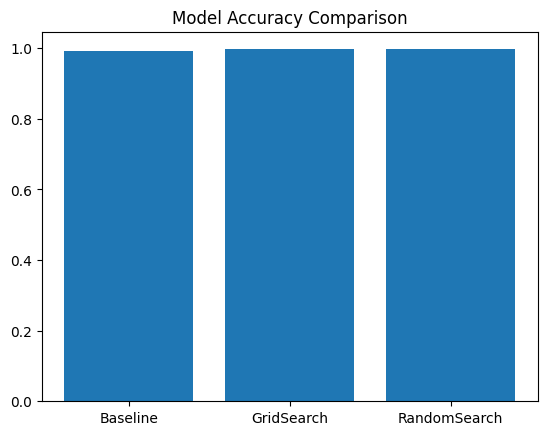

In [74]:
results = {
    "Baseline": baseline_acc,
    "GridSearch": grid_acc,
    "RandomSearch": random_acc
}

plt.bar(results.keys(), results.values())
plt.title("Model Accuracy Comparison")
plt.show()

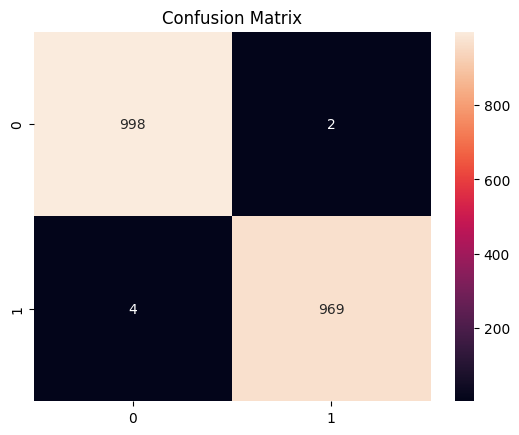

In [75]:
# visulizing Confusion Matrix
cm = confusion_matrix(y_test, best_model.predict(X_test))

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [76]:
import pickle

# Load model
with open("best_model.pkl", "rb") as f:
    model = pickle.load(f)

print("\n===============================")
print("        FAKE NEWS DETECTOR")
print("===============================")

while True:
    text = input("\nEnter text (or type 'exit'): ")

    if text.lower() == 'exit':
        break

    # Preprocess input text
    processed_text = preprocess_text(text)

    # Prediction
    pred = model.predict([processed_text])[0]

    # Convert label back to original
    result = label_encoder.inverse_transform([pred])[0]

    print("\nPrediction (Tuned Model):", result)
    print("-------------------------------")


        FAKE NEWS DETECTOR

Prediction (Tuned Model): Real
-------------------------------

Prediction (Tuned Model): Fake
-------------------------------
